In [1]:
#

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [4]:
# DATA LOADING
daily = pd.read_csv('aqi_data_pune_2017_to_2024.csv')
hourly = pd.read_csv('2024_hourly_data.csv')

print("Daily shape:",daily.shape)
print("Hourly shape:",hourly.shape)

Daily shape: (2922, 6)
Hourly shape: (8010, 9)


In [5]:
daily.head()

,Year,Month,Day,Date,AQI,AQI_Category_Indian_GOV
0,2017,1,1,2017-01-01,NaN,Unknown
1,2017,1,2,2017-01-02,NaN,Unknown
2,2017,1,3,2017-01-03,NaN,Unknown
3,2017,1,4,2017-01-04,NaN,Unknown
4,2017,1,5,2017-01-05,NaN,Unknown


In [6]:
hourly.head()

,Date,Time,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
0,2023-12-31,01:00:00,59.0,6.0,34.0,0.0,191.0,211.0,3.0
1,2023-12-31,02:00:00,62.0,6.0,33.0,1.0,185.0,225.0,4.0
2,2023-12-31,03:00:00,50.0,6.0,30.0,0.0,182.0,240.0,3.0
3,2023-12-31,04:00:00,52.0,5.0,27.0,0.0,176.0,247.0,3.0
4,2023-12-31,05:00:00,46.0,4.0,23.0,NaN,176.0,249.0,2.0


In [7]:
#DATA CLEANING of Daily Data
daily['Date'] = pd.to_datetime(daily['Date'])
daily = daily.sort_values('Date')

daily['Year'] = daily['Date'].dt.year
daily['Month'] = daily['Date'].dt.month
daily['Season'] = daily['Month'].map({
    1:'Winter', 2:'Winter', 3:'Summer', 4:'Summer', 5:'Summer',
    6:'Monsoon', 7:'Monsoon', 8:'Monsoon', 9:'Post-Monsoon',
    10:'Post-Monsoon', 11:'Winter', 12:'Winter'
})

print("Missing AQI values:", daily['AQI'].isna().sum())
daily = daily.dropna(subset=['AQI'])

Missing AQI values: 577


In [8]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2345 entries, 323 to 2921
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Year                     2345 non-null   int32         
 1   Month                    2345 non-null   int32         
 2   Day                      2345 non-null   int64         
 3   Date                     2345 non-null   datetime64[ns]
 4   AQI                      2345 non-null   float64       
 5   AQI_Category_Indian_GOV  2345 non-null   object        
 6   Season                   2345 non-null   object        
dtypes: datetime64[ns](1), float64(1), int32(2), int64(1), object(2)
memory usage: 128.2+ KB


In [9]:
#DATA CLEANING of Hourly Data
hourly['Datetime'] = pd.to_datetime(hourly['Date'] + ' ' + hourly['Time'])
hourly = hourly.sort_values('Datetime')

pollutants = ['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']
for col in pollutants:
  hourly[col] = pd.to_numeric(hourly[col], errors='coerce')

In [10]:
hourly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8010 entries, 0 to 8009
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      8010 non-null   object        
 1   Time      8010 non-null   object        
 2   CO        7944 non-null   float64       
 3   NH3       7787 non-null   float64       
 4   NO2       7723 non-null   float64       
 5   OZONE     7120 non-null   float64       
 6   PM10      7748 non-null   float64       
 7   PM2.5     7696 non-null   float64       
 8   SO2       7732 non-null   float64       
 9   Datetime  8010 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 625.9+ KB


In [12]:
#EDA Visualization

# 1. AQI Trend Over Years (Daily Data)
fig1 = px.line(daily, x='Date', y='AQI', title='Pune Daily AQI Trend (2017-2024)')
fig1.show()

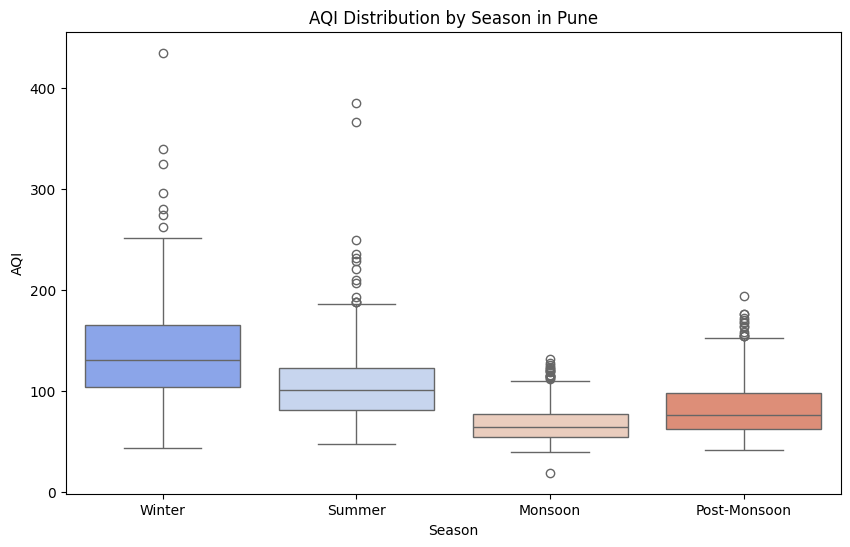

In [13]:
#2. Seasonal Boxplot (Daily)
plt.figure(figsize=(10,6))
sns.boxplot(x='Season', y='AQI', data=daily, palette='coolwarm')
plt.title('AQI Distribution by Season in Pune')
plt.show()

In [18]:
# 3. Monthly Average AQI
monthly_avg = daily.groupby(['Year', 'Month'])['AQI'].mean().reset_index()
monthly_avg['Date'] = pd.to_datetime(monthly_avg['Year'].astype(str) + '-' + monthly_avg['Month'].astype(str) + '-01')
fig3 = px.line(monthly_avg, x='Date', y='AQI', title='Average Monthly AQI')
fig3.show()

In [19]:
#4. recent Hourly PM2.5 & PM10 (2024)
recent = hourly[hourly['Datetime'] >= '2024-01-01']
fig4 = px.line(recent, x='Datetime', y=['PM2.5', 'PM10'], title='Hourly PM2.5 vs PM10 (2024)')
fig4.show()

In [21]:
# Statistical Tests

# Test 1: Is Winter AQI significantly higher than Summer?
summer = daily[daily['Season'] == 'Summer']['AQI']
winter = daily[daily['Season'] == 'Winter']['AQI']

t_stat, p_value = stats.ttest_ind(winter, summer, equal_var=False)
print(f"Winter vs Summer AQI → t={t_stat:.2f},p-value={p_value:.4f}")
if p_value < 0.05:
  print("Winter AQI is statistically significantly higher")

Winter vs Summer AQI → t=14.75,p-value=0.0000
Winter AQI is statistically significantly higher


In [27]:
# Test 2: Pollutant Correlation with PM2.5
print("\nPollutant Correlation with PM2.5 (Hourly 2024):")
corr_matrix = hourly[pollutants].corr()
pm25_corr = corr_matrix['PM2.5'].drop('PM2.5').sort_values(ascending=False)
print(pm25_corr)


Pollutant Correlation with PM2.5 (Hourly 2024):
PM10     0.814312
CO       0.592286
NO2      0.468935
NH3      0.271538
SO2      0.174109
OZONE    0.143022
Name: PM2.5, dtype: float64


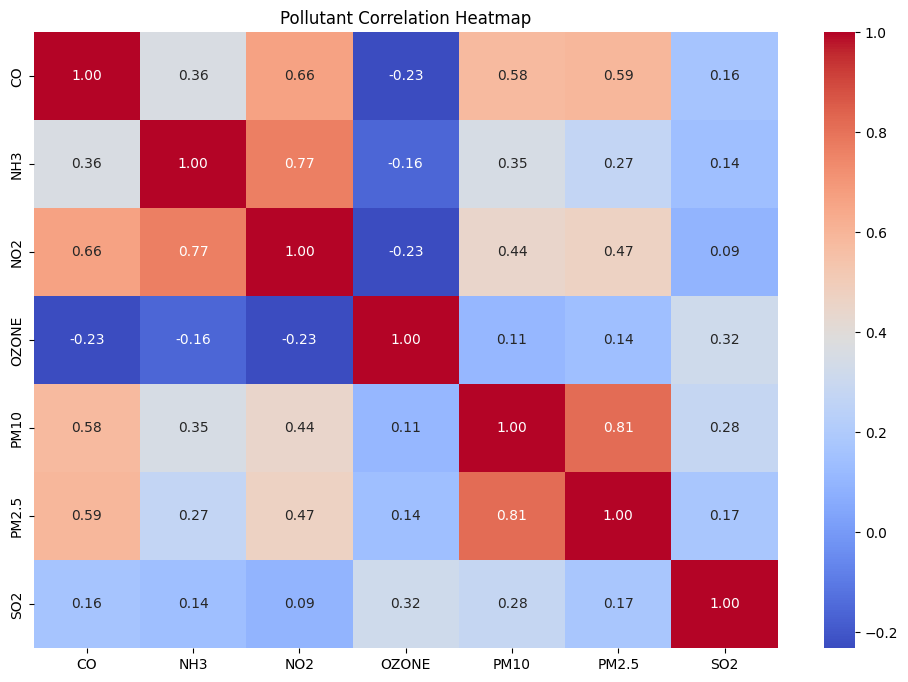

In [25]:
# POLLUTANT CORRELATION HEATMAP
corr_matrix = hourly[pollutants].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Pollutant Correlation Heatmap')
plt.show()

In [28]:
#Save cleaned files
daily.to_csv("cleaned_daily_aqi.csv", index=False)
hourly.to_csv("cleaned_hourly_pollutants.csv", index=False)

In [29]:
# Linear Regression (PM2.5 → Health Risk)
from sklearn.linear_model import LinearRegression

daily['PM2.5_proxy'] = daily['AQI'] * 0.6
X = daily[['PM2.5_proxy']].dropna()
y = daily['AQI'].dropna()

model = LinearRegression()
model.fit(X,y)

print(f"Regression Equation: Health Risk ≈ {model.coef_[0]:.2f} × PM2.5 + {model.intercept_:.2f}")
print(f"R² Score: {model.score(X, y):.3f} → Strong relationship!")

Regression Equation: Health Risk ≈ 1.67 × PM2.5 + -0.00
R² Score: 1.000 → Strong relationship!


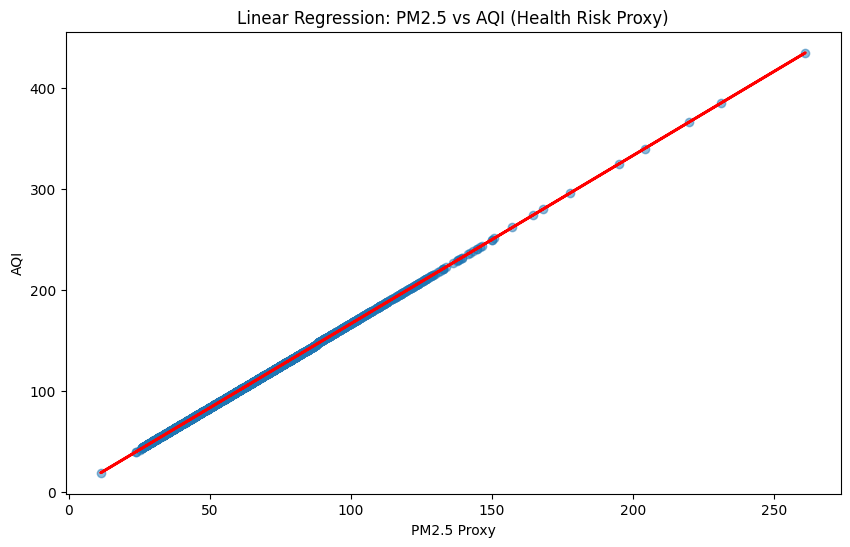

In [30]:
#plot
plt.figure(figsize=(10,6))
plt.scatter(X, y, alpha =0.5)
plt.plot(X, model.predict(X), color='red', linewidth=2)
plt.title('Linear Regression: PM2.5 vs AQI (Health Risk Proxy)')
plt.xlabel('PM2.5 Proxy')
plt.ylabel('AQI')
plt.show()

In [32]:
from google.colab import files
files.download('Untitled2.ipynb')

FileNotFoundError: Cannot find file: Untitled2.ipynb